# Mi8 Multipath — Exploratory Data Analysis & Feature Engineering

Explores the Mi8 GNSS measurement dataset and engineers features for the classifier. The label is the device's own `MultipathIndicator`.

**Input:** `data/02_interim/mi8_epochs.csv`

**Output:** `data/03_processed/mi8_training_features.csv`

## 1. Library Import & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '../..'))
INPUT_CSV  = os.path.join(BASE_DIR, 'data/02_interim/mi8_epochs.csv')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data/03_processed')
OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'mi8_training_features.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_CSV)
pd.set_option('display.max_columns', None)
print(f'Loaded {len(df):,} rows from {INPUT_CSV}')
df.head()

Loaded 333,070 rows from c:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/02_interim/mi8_epochs.csv


,State,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,MultipathIndicator,SnrInDb,ConstellationType,AgcDb,BasebandCn0DbHz,session,GpsTimeNanos
0,16431,60,20.319111,-506.976813,1.035816,4,-1.975864e+06,3.402823e+38,1.575420e+09,0,NaN,1,NaN,NaN,2020-07-17-US-MTV-1,512735000490398
1,16431,68,18.665722,194.196981,1.109674,4,4.279438e+04,3.402823e+38,1.575420e+09,1,NaN,1,NaN,NaN,2020-07-17-US-MTV-1,512735000490398
2,16431,79,16.907887,-1.292387,1.189805,4,-5.546913e+05,3.402823e+38,1.575420e+09,1,NaN,1,NaN,NaN,2020-07-17-US-MTV-1,512735000490398
3,16431,34,27.375841,-115.461983,0.007329,1,-5.378665e+05,3.664354e-03,1.575420e+09,0,NaN,1,NaN,NaN,2020-07-17-US-MTV-1,512735000490398
4,16431,64,19.540489,29.656072,1.072106,4,-1.012807e+05,3.402823e+38,1.575420e+09,0,NaN,1,NaN,NaN,2020-07-17-US-MTV-1,512735000490398


## 2. Dataset Overview

In [2]:
print('--- Info ---')
df.info()
print('\n--- Statistical Summary ---')
df.describe()

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333070 entries, 0 to 333069
Data columns (total 16 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   State                                      333070 non-null  int64  
 1   ReceivedSvTimeUncertaintyNanos             333070 non-null  int64  
 2   Cn0DbHz                                    333070 non-null  float64
 3   PseudorangeRateMetersPerSecond             333070 non-null  float64
 4   PseudorangeRateUncertaintyMetersPerSecond  333070 non-null  float64
 5   AccumulatedDeltaRangeState                 333070 non-null  int64  
 6   AccumulatedDeltaRangeMeters                333070 non-null  float64
 7   AccumulatedDeltaRangeUncertaintyMeters     333070 non-null  float64
 8   CarrierFrequencyHz                         333070 non-null  float64
 9   MultipathIndicator                         333070 non-null  int64  


,State,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,MultipathIndicator,SnrInDb,ConstellationType,AgcDb,BasebandCn0DbHz,GpsTimeNanos
count,333070.000000,333070.000000,333070.000000,333070.000000,333070.000000,333070.000000,3.330700e+05,3.330700e+05,3.330700e+05,333070.000000,0.0,333070.000000,114213.000000,0.0,3.330700e+05
mean,17116.221494,20.655006,32.630600,2.597270,9.180785,7.297841,-2.571700e+05,9.201835e+37,1.456678e+09,0.032396,NaN,3.424679,41.619278,NaN,4.350400e+14
std,1138.181740,18.428766,6.032700,8809.509694,51.138090,7.734360,1.216061e+06,1.511453e+38,1.797964e+08,0.177049,NaN,2.312797,19.319797,NaN,1.264374e+14
min,16393.000000,6.000000,8.039667,-524105.768269,0.000908,1.000000,-3.933641e+06,4.538255e-04,1.176450e+09,0.000000,NaN,1.000000,6.020600,NaN,1.637780e+14
25%,16431.000000,10.000000,28.801486,-352.853452,0.002832,1.000000,-1.003379e+06,1.467607e-03,1.176450e+09,0.000000,NaN,1.000000,11.695103,NaN,4.288340e+14
50%,16431.000000,15.000000,33.687445,-17.200688,0.004608,4.000000,-1.080456e+05,2.558657e-03,1.575420e+09,0.000000,NaN,5.000000,48.692570,NaN,4.971340e+14
75%,17466.000000,24.000000,37.089551,331.774713,0.307149,17.000000,3.120198e+05,3.402823e+38,1.575420e+09,0.000000,NaN,6.000000,49.160927,NaN,5.136960e+14
max,19498.000000,498.000000,46.566433,524178.482037,299.797263,22.000000,4.327834e+06,3.402823e+38,1.605375e+09,1.000000,NaN,6.000000,64.860497,NaN,5.173540e+14


## 3. Target Variable Distribution

Checks overall class balance and per-session breakdown.

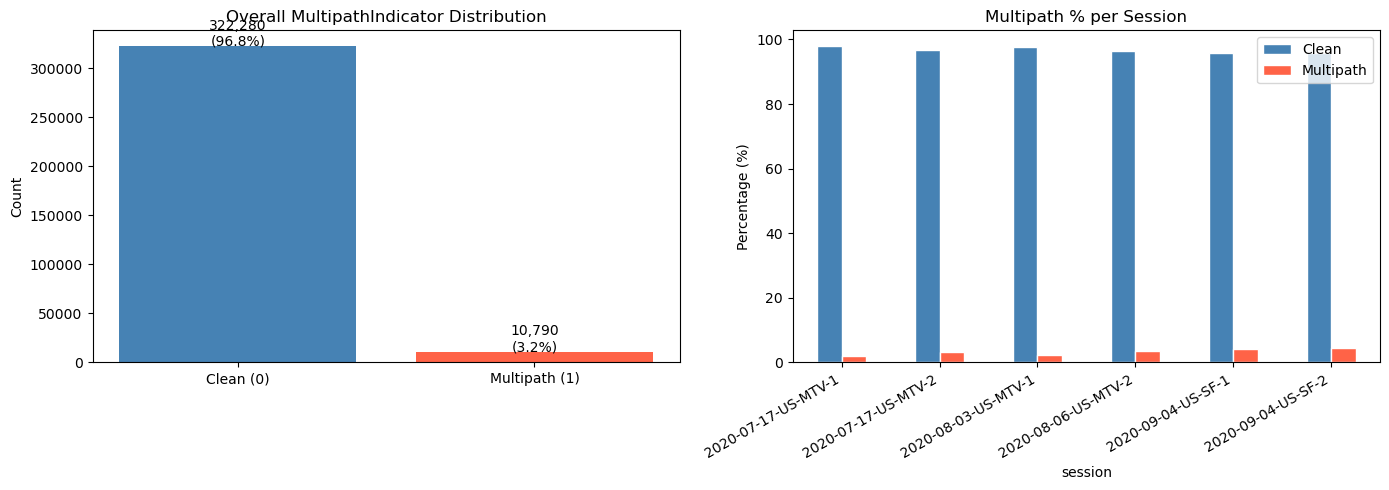

Class imbalance: 3.2% multipath


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
counts = df['MultipathIndicator'].value_counts()
axes[0].bar(['Clean (0)', 'Multipath (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Overall MultipathIndicator Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center')

# Per session
sess_pct = (
    df.groupby(['session', 'MultipathIndicator'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: 100 * r / r.sum(), axis=1)
)
sess_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Multipath % per Session')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(['Clean', 'Multipath'])

plt.tight_layout()
plt.show()
print(f'Class imbalance: {100*counts[1]/len(df):.1f}% multipath')

## 4. Feature Distributions by Class

Boxplots comparing the key measurement features between clean and multipath epochs.

C:\Users\Dell\AppData\Local\Temp\ipykernel_25240\2198835784.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_25240\2198835784.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_25240\2198835784.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_25240\2198835784.py:18: MatplotlibDe

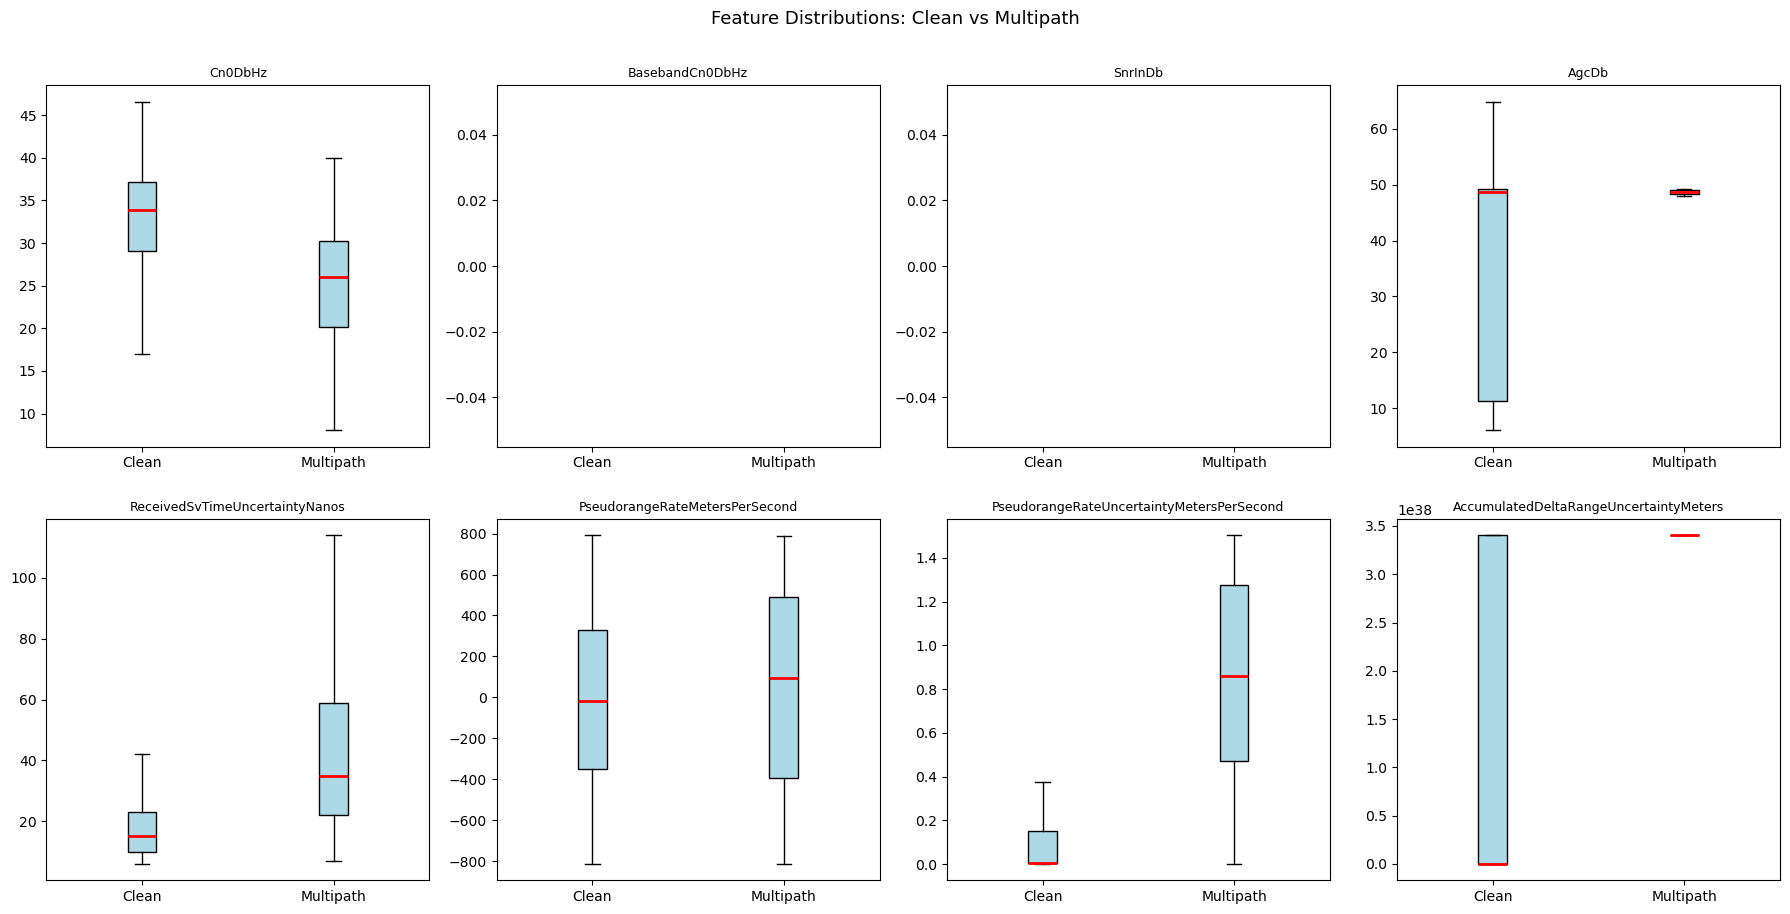

In [4]:
PLOT_FEATURES = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'ReceivedSvTimeUncertaintyNanos',
    'PseudorangeRateMetersPerSecond',
    'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeUncertaintyMeters',
]
available_plot = [f for f in PLOT_FEATURES if f in df.columns]

n = len(available_plot)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(available_plot):
    ax = axes[i]
    data_plot = df[[feat, 'MultipathIndicator']].dropna()
    groups = [data_plot.loc[data_plot['MultipathIndicator'] == v, feat] for v in [0, 1]]
    ax.boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2),
               showfliers=False)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Clean vs Multipath', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Constellation Breakdown

ConstellationType codes: 1=GPS, 3=GLONASS, 5=BeiDou, 6=Galileo. Checks whether certain constellations are more prone to multipath flagging.

MultipathIndicator   Clean  Multipath  Multipath_%
ConstellationName                                 
QZSS                  5589        731         11.6
GLONASS               1917        214         10.0
GPS                 149083       6288          4.0
BeiDou               59947       1927          3.1
Galileo             105744       1630          1.5


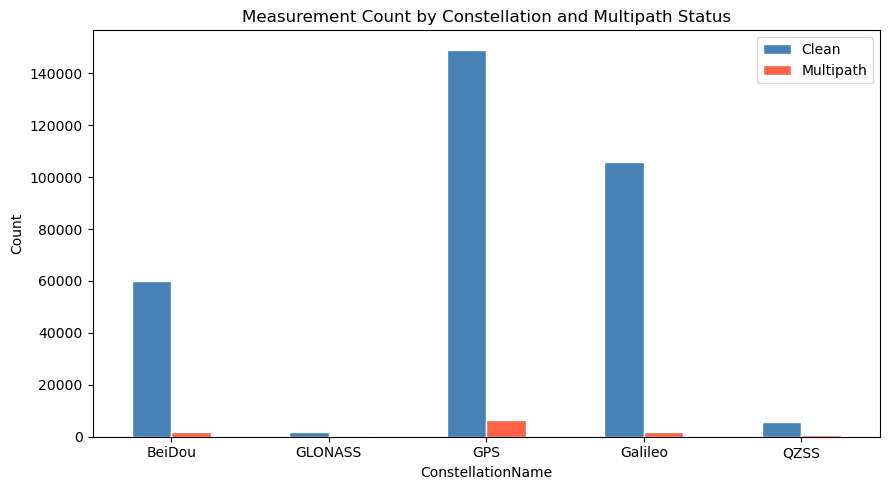

In [5]:
CONST_NAMES = {1: 'GPS', 2: 'SBAS', 3: 'GLONASS', 4: 'QZSS', 5: 'BeiDou', 6: 'Galileo'}
df['ConstellationName'] = df['ConstellationType'].map(CONST_NAMES).fillna('Unknown')

const_mp = (
    df.groupby(['ConstellationName', 'MultipathIndicator'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Clean', 1: 'Multipath'})
)
if 'Multipath' in const_mp.columns and 'Clean' in const_mp.columns:
    const_mp['Multipath_%'] = (100 * const_mp['Multipath'] / const_mp.sum(axis=1)).round(1)

print(const_mp.sort_values('Multipath_%', ascending=False))

const_mp[['Clean', 'Multipath']].plot(
    kind='bar', figsize=(9, 5),
    color=['steelblue', 'tomato'], edgecolor='white'
)
plt.title('Measurement Count by Constellation and Multipath Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Clean', 'Multipath'])
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

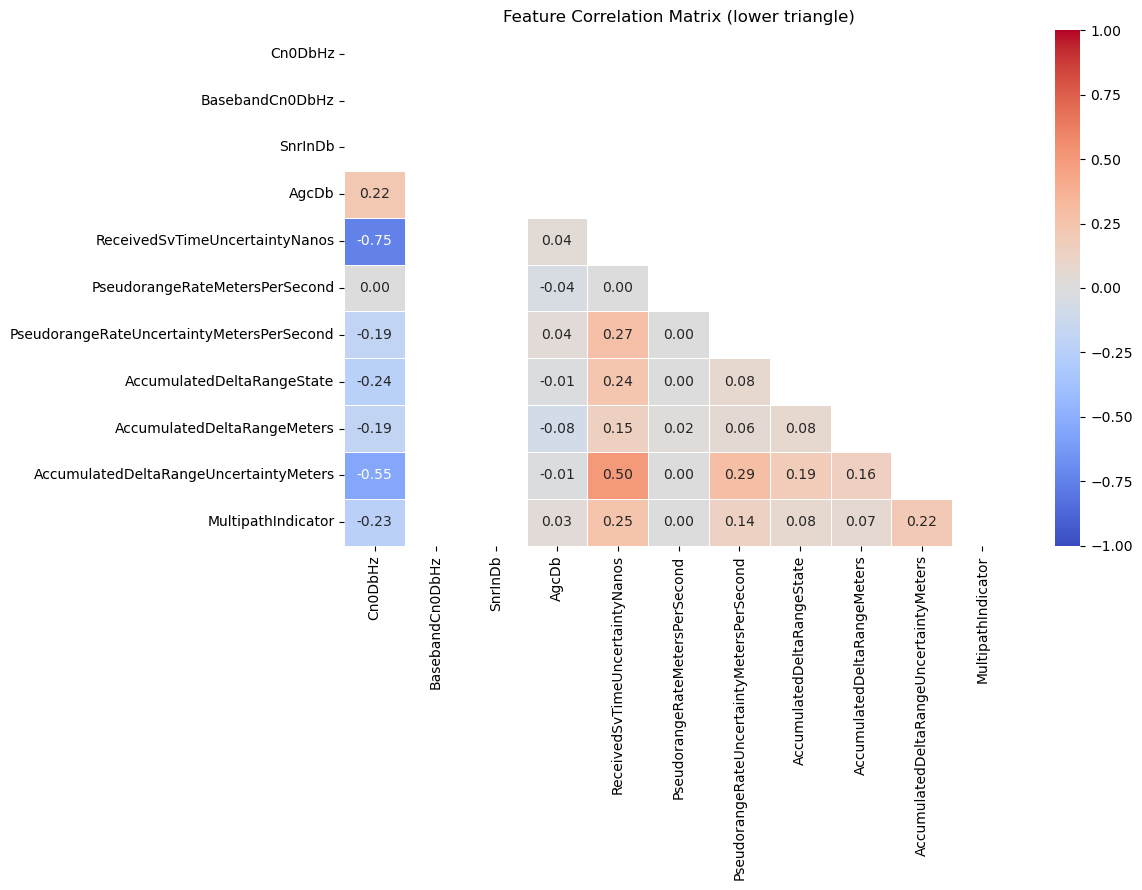


Correlation with MultipathIndicator (sorted):
ReceivedSvTimeUncertaintyNanos               0.254970
Cn0DbHz                                     -0.234411
AccumulatedDeltaRangeUncertaintyMeters       0.215295
PseudorangeRateUncertaintyMetersPerSecond    0.137437
AccumulatedDeltaRangeState                   0.076172
AccumulatedDeltaRangeMeters                  0.066344
AgcDb                                        0.032754
PseudorangeRateMetersPerSecond               0.001206
BasebandCn0DbHz                                   NaN
SnrInDb                                           NaN
Name: MultipathIndicator, dtype: float64


In [6]:
NUMERIC_FEATS = [
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'ReceivedSvTimeUncertaintyNanos',
    'PseudorangeRateMetersPerSecond',
    'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeState',
    'AccumulatedDeltaRangeMeters',
    'AccumulatedDeltaRangeUncertaintyMeters',
    'MultipathIndicator',
]
available_num = [f for f in NUMERIC_FEATS if f in df.columns]
corr = df[available_num].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

print('\nCorrelation with MultipathIndicator (sorted):')
print(corr['MultipathIndicator'].drop('MultipathIndicator').sort_values(key=abs, ascending=False))

## 7. Cn0DbHz Deep Dive

Scatter of C/N0 coloured by multipath flag, and a KDE density comparison.

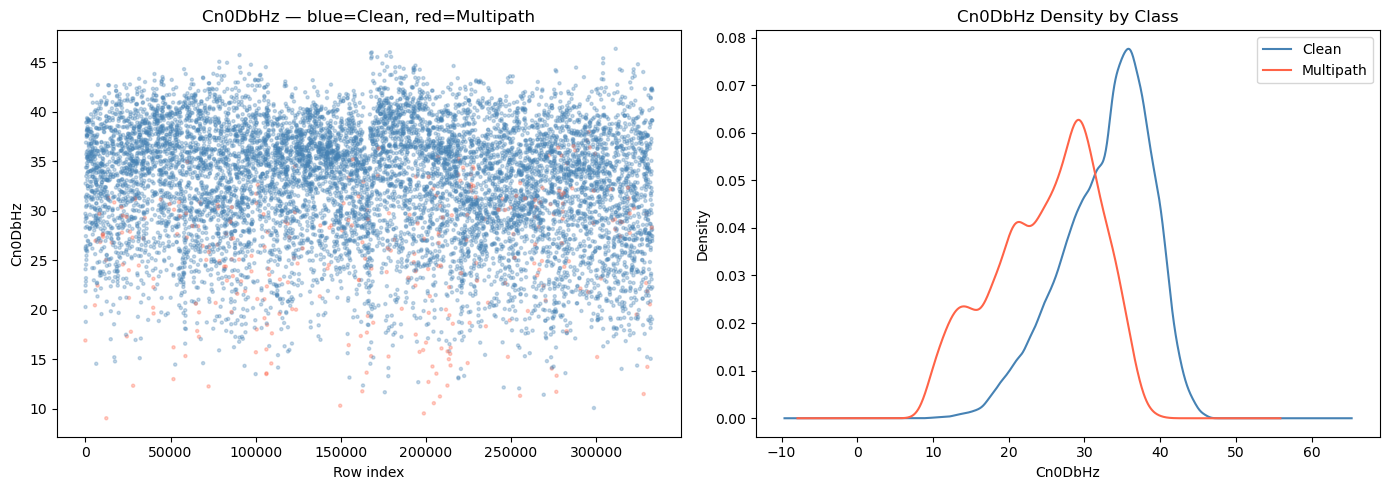

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(10000, len(df)), random_state=42)
colors = sample['MultipathIndicator'].map({0: 'steelblue', 1: 'tomato'})
axes[0].scatter(sample.index, sample['Cn0DbHz'], c=colors, alpha=0.3, s=5)
axes[0].set_title('Cn0DbHz — blue=Clean, red=Multipath')
axes[0].set_xlabel('Row index')
axes[0].set_ylabel('Cn0DbHz')

for val, label, color in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    subset = df.loc[df['MultipathIndicator'] == val, 'Cn0DbHz'].dropna()
    subset.plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Cn0DbHz Density by Class')
axes[1].set_xlabel('Cn0DbHz')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Engineering

Creates additional features: signal-strength category (Cn0 bins), constellation one-hot encoding, and drops non-predictive columns.

In [8]:
df_ml = df.copy()

# Cn0DbHz signal strength bucket
df_ml['Cn0_Category'] = pd.cut(
    df_ml['Cn0DbHz'],
    bins=[0, 20, 30, 40, np.inf],
    labels=['VeryWeak', 'Weak', 'Medium', 'Strong'],
    right=False
)

# One-hot encode constellation
df_ml = pd.get_dummies(df_ml, columns=['ConstellationName'], prefix='Const')

# Drop identifier / non-feature columns
DROP_COLS = ['session', 'GpsTimeNanos', 'State', 'ConstellationType', 'CarrierFrequencyHz']
df_ml.drop(columns=[c for c in DROP_COLS if c in df_ml.columns], inplace=True)

print('Features after engineering:')
print(list(df_ml.columns))
df_ml.head()

Features after engineering:
['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SnrInDb', 'AgcDb', 'BasebandCn0DbHz', 'Cn0_Category', 'Const_BeiDou', 'Const_GLONASS', 'Const_GPS', 'Const_Galileo', 'Const_QZSS']


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,SnrInDb,AgcDb,BasebandCn0DbHz,Cn0_Category,Const_BeiDou,Const_GLONASS,Const_GPS,Const_Galileo,Const_QZSS
0,60,20.319111,-506.976813,1.035816,4,-1.975864e+06,3.402823e+38,0,NaN,NaN,NaN,Weak,False,False,True,False,False
1,68,18.665722,194.196981,1.109674,4,4.279438e+04,3.402823e+38,1,NaN,NaN,NaN,VeryWeak,False,False,True,False,False
2,79,16.907887,-1.292387,1.189805,4,-5.546913e+05,3.402823e+38,1,NaN,NaN,NaN,VeryWeak,False,False,True,False,False
3,34,27.375841,-115.461983,0.007329,1,-5.378665e+05,3.664354e-03,0,NaN,NaN,NaN,Weak,False,False,True,False,False
4,64,19.540489,29.656072,1.072106,4,-1.012807e+05,3.402823e+38,0,NaN,NaN,NaN,VeryWeak,False,False,True,False,False


## 9. Data Quality Check

In [9]:
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_counts = df_ml.isnull().sum()
print('NaN counts per column:')
print(nan_counts[nan_counts > 0] if (nan_counts > 0).any() else '  None')

# Drop columns that are entirely NaN — they carry no information.
all_nan_cols = nan_counts[nan_counts == len(df_ml)].index.tolist()
if all_nan_cols:
    df_ml.drop(columns=all_nan_cols, inplace=True)
    print(f'\nDropped all-NaN columns: {all_nan_cols}')

# Fill AgcDb (partially populated) with its median.
if 'AgcDb' in df_ml.columns and df_ml['AgcDb'].isna().any():
    df_ml['AgcDb'].fillna(df_ml['AgcDb'].median(), inplace=True)
    print('Filled AgcDb NaN with median')

# Only drop rows where the core predictive features are missing.
CORE_COLS = [
    'Cn0DbHz', 'ReceivedSvTimeUncertaintyNanos',
    'PseudorangeRateMetersPerSecond', 'AccumulatedDeltaRangeState',
    'MultipathIndicator',
]
core_present = [c for c in CORE_COLS if c in df_ml.columns]
before = len(df_ml)
df_ml.dropna(subset=core_present, inplace=True)
print(f'\nRows dropped (missing core): {before - len(df_ml):,}  |  Remaining: {len(df_ml):,}')
print(f'Final columns: {list(df_ml.columns)}')

NaN counts per column:
SnrInDb            333070
AgcDb              218857
BasebandCn0DbHz    333070
dtype: int64

Dropped all-NaN columns: ['SnrInDb', 'BasebandCn0DbHz']
Filled AgcDb NaN with median

Rows dropped (missing core): 0  |  Remaining: 333,070
Final columns: ['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'AgcDb', 'Cn0_Category', 'Const_BeiDou', 'Const_GLONASS', 'Const_GPS', 'Const_Galileo', 'Const_QZSS']


C:\Users\Dell\AppData\Local\Temp\ipykernel_25240\1771267230.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['AgcDb'].fillna(df_ml['AgcDb'].median(), inplace=True)


## 10. Encode Cn0_Category\n\n⚠️ **No scaling here.** StandardScaler must be fitted on training data only — fitting on the full dataset leaks test-set statistics. Scaling and SMOTE are done inside the classifier notebook after the train/test split.

In [10]:
# Encode Cn0_Category (idempotent guard for re-runs)
if 'Cn0_Category' in df_ml.columns:
    df_ml = pd.get_dummies(df_ml, columns=['Cn0_Category'], prefix='Cn0_Cat')
else:
    print('Cn0_Category already encoded — skipping')

print(f'Columns after encoding: {list(df_ml.columns)}')
print(f'Shape: {df_ml.shape}')

Columns after encoding: ['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'AgcDb', 'Const_BeiDou', 'Const_GLONASS', 'Const_GPS', 'Const_Galileo', 'Const_QZSS', 'Cn0_Cat_VeryWeak', 'Cn0_Cat_Weak', 'Cn0_Cat_Medium', 'Cn0_Cat_Strong']
Shape: (333070, 18)


## 11. Class Imbalance — Overview\n\nShows the raw imbalance before any resampling. SMOTE is applied **inside the classifier notebook on training data only** to avoid leakage.

In [11]:
X = df_ml.drop(columns=['MultipathIndicator'])
y = df_ml['MultipathIndicator'].astype(int)

counts = y.value_counts()
total  = len(y)
print('Class distribution (raw, pre-split):')
for cls, cnt in counts.items():
    print(f'  {cls}: {cnt:,}  ({100*cnt/total:.1f}%)')
print(f'\nImbalance ratio: {counts[0]/counts[1]:.1f}:1  →  SMOTE will balance this in the classifier.')

Class distribution (raw, pre-split):
  0: 322,280  (96.8%)
  1: 10,790  (3.2%)

Imbalance ratio: 29.9:1  →  SMOTE will balance this in the classifier.


## 12. PCA — Variance Explained (on raw unscaled features)\n\nFor orientation only — uses the unscaled feature matrix so PCA reflects true variance magnitudes.

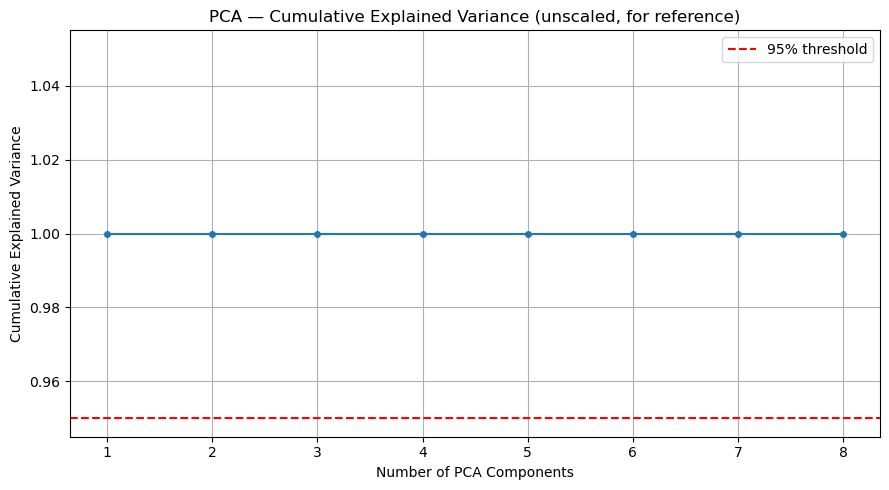

Components needed to explain 95% of variance: 1


In [12]:
bool_cols = X.select_dtypes(include='bool').columns.tolist()
num_cols  = [c for c in X.select_dtypes(include=np.number).columns if c not in bool_cols]

pca = PCA()
pca.fit(X[num_cols].fillna(0))
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (unscaled, for reference)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

n95 = int(np.where(cumvar >= 0.95)[0][0]) + 1
print(f'Components needed to explain 95% of variance: {n95}')

## 13. Export Training Features

In [13]:
# Export raw (unscaled, pre-SMOTE) features.
# Scaling and SMOTE are applied in 03_mi8_classification.ipynb AFTER the
# train/test split to prevent leakage of test-set statistics.
df_ml.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(df_ml):,} rows  →  {OUTPUT_CSV}')
print(f'Shape: {df_ml.shape}')
df_ml.head()

Saved 333,070 rows  →  c:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed\mi8_training_features.csv
Shape: (333070, 18)


,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,AccumulatedDeltaRangeState,AccumulatedDeltaRangeMeters,AccumulatedDeltaRangeUncertaintyMeters,MultipathIndicator,AgcDb,Const_BeiDou,Const_GLONASS,Const_GPS,Const_Galileo,Const_QZSS,Cn0_Cat_VeryWeak,Cn0_Cat_Weak,Cn0_Cat_Medium,Cn0_Cat_Strong
0,60,20.319111,-506.976813,1.035816,4,-1.975864e+06,3.402823e+38,0,48.69257,False,False,True,False,False,False,True,False,False
1,68,18.665722,194.196981,1.109674,4,4.279438e+04,3.402823e+38,1,48.69257,False,False,True,False,False,True,False,False,False
2,79,16.907887,-1.292387,1.189805,4,-5.546913e+05,3.402823e+38,1,48.69257,False,False,True,False,False,True,False,False,False
3,34,27.375841,-115.461983,0.007329,1,-5.378665e+05,3.664354e-03,0,48.69257,False,False,True,False,False,False,True,False,False
4,64,19.540489,29.656072,1.072106,4,-1.012807e+05,3.402823e+38,0,48.69257,False,False,True,False,False,True,False,False,False
